Imports

In [97]:
import mysql.connector
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import kruskal

import textwrap


In [ ]:
data_dir = Path("../Data")
input_file = data_dir / "2026-07-06_3_bank_dataset_transformed.csv"

df = pd.read_csv(input_file, encoding="utf-8-sig")

print(f"Dataset loaded from: {input_file.resolve()}")
print(f"Shape: {df.shape}")



Dataset loaded from: C:\Users\nowan\Documents\itacademy\Simulador\ProjecteData\Equip_32\Data\2026-07-06_3_bank_dataset_transformed.csv
Shape: (10975, 28)


,id,age,job,marital,education,default,balance,housing,loan,contact,...,no_previous_contact,had_previous_contact,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3
5,6,42.0,management,single,tertiary,no,0,yes,yes,unknown,...,1,0,Adult (36-50),2,High burden,3.0,Tertiary,White Collar,1,0-3
6,7,56.0,management,married,tertiary,no,830,yes,yes,unknown,...,1,0,Middle-Aged (51-65),2,High burden,3.0,Tertiary,White Collar,1,0-3
7,8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Retired,1,0-3
8,9,37.0,technician,married,secondary,no,1,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
9,10,28.0,services,single,secondary,no,5090,yes,no,unknown,...,1,0,Young Adult (26-35),1,Low burden,2.0,Secondary,Blue Collar,1,0-3


In [92]:
# Renombrar concepte: financial_burden -> engagement (nombre de productes contractats com a indicador de vinculació, no de càrrega)
df = df.rename(columns={
    "financial_burden": "engagement",
    "financial_burden_label": "engagement_label"
})

engagement_map = {
    "No burden": "Low engagement",
    "Low burden": "Medium engagement",
    "High burden": "High engagement"
}
df["engagement_label"] = df["engagement_label"].map(engagement_map)

print(df["engagement_label"].value_counts())

engagement_label
Low engagement       5185
Medium engagement    4972
High engagement       818
Name: count, dtype: int64


In [126]:
df.head(10)

,id,age,job,marital,education,default,balance,housing,loan,contact,...,engagement,engagement_label,education_rank,education_label,job_profile,week_of_month,campaign_group,segment,segment_label,credit_combination
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,1,Medium engagement,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados,housing_yes_loan_no
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,0,Low engagement,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados,housing_no_loan_no
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,1,Medium engagement,2.0,Secondary,White Collar,1,0-3,Cluster_1,Trabajadores técnicos,housing_yes_loan_no
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,1,Medium engagement,2.0,Secondary,Blue Collar,1,0-3,Cluster_0,Adultos consolidados,housing_yes_loan_no
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,0,Low engagement,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados,housing_no_loan_no
5,6,42.0,management,single,tertiary,no,0,yes,yes,unknown,...,2,High engagement,3.0,Tertiary,White Collar,1,0-3,Cluster_2,Professionales estudios superiores,housing_yes_loan_yes
6,7,56.0,management,married,tertiary,no,830,yes,yes,unknown,...,2,High engagement,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados,housing_yes_loan_yes
7,8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,...,1,Medium engagement,2.0,Secondary,Retired,1,0-3,Retired,Jubilados,housing_yes_loan_no
8,9,37.0,technician,married,secondary,no,1,yes,no,unknown,...,1,Medium engagement,2.0,Secondary,White Collar,1,0-3,Cluster_2,Professionales estudios superiores,housing_yes_loan_no
9,10,28.0,services,single,secondary,no,5090,yes,no,unknown,...,1,Medium engagement,2.0,Secondary,Blue Collar,1,0-3,Cluster_3,Jovenes en consolidación,housing_yes_loan_no


### Business Question

Which demographic characteristics are associated with a higher probability of subscribing to a term deposit?

### Analytical approach

This analysis focuses on demographic variables only. First, each demographic characteristic is evaluated individually. Then, the variables are combined to identify customer segments with the highest subscription rates.

In [49]:
# Reusable function to analyze demographic variables consistently.
# The function generates both a summary table and a bar chart.

def analyze_profile_variable(df, variable, order=None, sort=False, reverse_palette=False):

# Compute subscription rates and sample size for each demographic category
   
    summary = (
        df.groupby(variable, observed=True)["deposit"]
          .value_counts(normalize=True)
          .unstack()
          .mul(100)
          .rename(columns={
              1: "subscription_rate",
              0: "non_subscription_rate"
          })
          .round(1)
    )

    summary["n_clients"] = (
        df.groupby(variable, observed=True)
          .size()
    )

# Display the categories in a clear order

    if order is not None:
        summary = summary.reindex(order)
    elif sort:
        summary = summary.sort_values(
            by="subscription_rate",
            ascending=False
        )

    display(summary)

# Add sample size to x-axis labels

    summary["label"] = [
        f"{category}\nn={n:,}"
        for category, n in zip(summary.index, summary["n_clients"])
    ]

# Create a consistent colour palette for all demographic charts

    if reverse_palette:
        colors = ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"]
    else:
        colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#DDEFE6"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plot_data = summary.reset_index()

    plt.figure(figsize=(10,5))

    # Visualize subscription rates across demographic categories

    sns.barplot(
    data=plot_data,
    x="label",
    y="subscription_rate",
    hue="label",
    order=summary["label"],
    hue_order=summary["label"],
    palette=palette,
    legend=False,
    width=0.8,
    dodge=False)

    # Add subscription rates inside the bars
    
    for index, row in plot_data.iterrows():
        plt.text(
            x=index,
            y=row["subscription_rate"] / 2,
            s=f'{row["subscription_rate"]:.1f}%',
            ha="center",
            va="center",
            fontsize=10,
            color="#1F2D26",
            fontweight="normal"
        )

    plt.title(f"Deposit Subscription Rate by {variable.replace('_',' ').title()}")
    plt.xlabel(variable.replace("_"," ").title())
    plt.ylabel("Subscription Rate (%)")
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

### Age

Age is analysed first to determine whether subscription behaviour changes across different stages of life.

deposit,non_subscription_rate,subscription_rate,n_clients
age_group,,,
Senior (65+),19.6,80.4,397
Young (18-25),28.2,71.8,444
Middle-Aged (51-65),51.3,48.7,2039
Young Adult (26-35),51.4,48.6,3840
Adult (36-50),58.0,42.0,4255


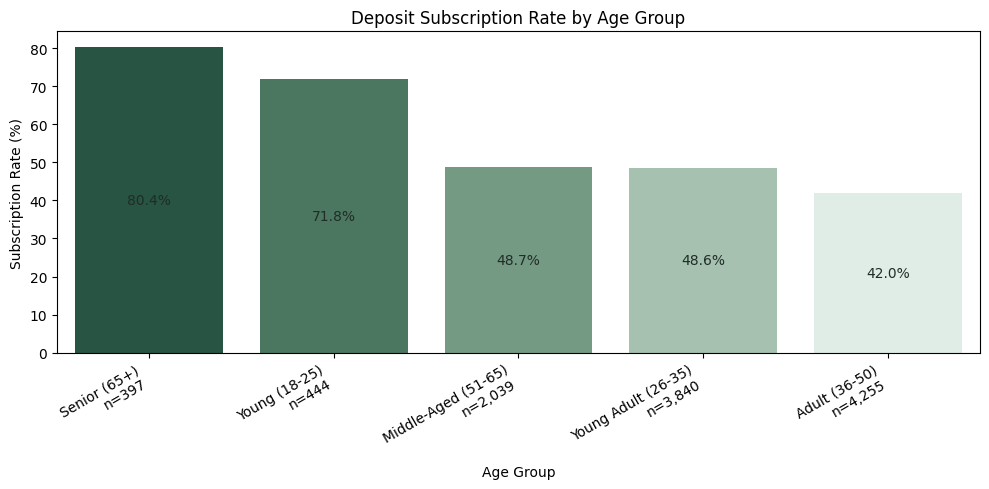

In [50]:
age_order = [
    "Young (18-25)",
    "Young Adult (26-35)",
    "Adult (36-50)",
    "Middle-Aged (51-65)",
    "Senior (65+)"
]

analyze_profile_variable(df, "age_group", sort=True)

Customers aged 60 and over present the highest conversion rate (around 78%), suggesting that older clients are considerably more likely to subscribe to a term depo
sit than younger age groups. This may be related to greater financial stability or more conservative investment preferences, although further analysis would be required to confirm these factors.


### Job profile

Occupational groups are compared to identify whether employment status influences customers' propensity to subscribe.

deposit,non_subscription_rate,subscription_rate,n_clients
job_profile,,,
Student,25.1,74.9,358
Retired,33.0,67.0,769
Unemployed,41.6,58.4,346
White Collar,50.9,49.1,5639
Unknown,51.4,48.6,70
Self-Employed,56.8,43.2,717
Blue Collar,61.4,38.6,3076


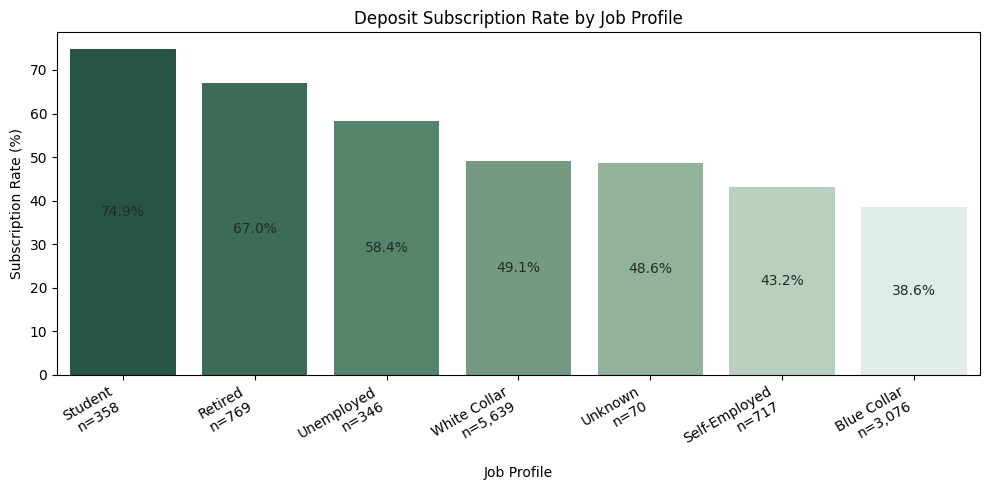

In [51]:
analyze_profile_variable(df, "job_profile", sort=True)

Students and retired customers exhibit the highest subscription rates, while operational occupations show the lowest conversion.
This suggests that employment profile is an important differentiating factor in customer behaviour.

In [52]:
pd.crosstab(
    df["job"],
    df["deposit"],
    normalize="index"
).mul(100).round(1)

deposit,0,1
job,,
admin.,52.1,47.9
blue-collar,62.8,37.2
entrepreneur,61.4,38.6
housemaid,59.2,40.8
management,48.7,51.3
retired,33.0,67.0
self-employed,53.0,47.0
services,59.2,40.8
student,25.1,74.9


### Education

Education level is evaluated as a potential indicator of financial behaviour and product adoption.

deposit,non_subscription_rate,subscription_rate,n_clients
education_label,,,
Tertiary,45.2,54.8,3637
Unknown,48.3,51.7,487
Secondary,54.6,45.4,5385
Primary,59.7,40.3,1466


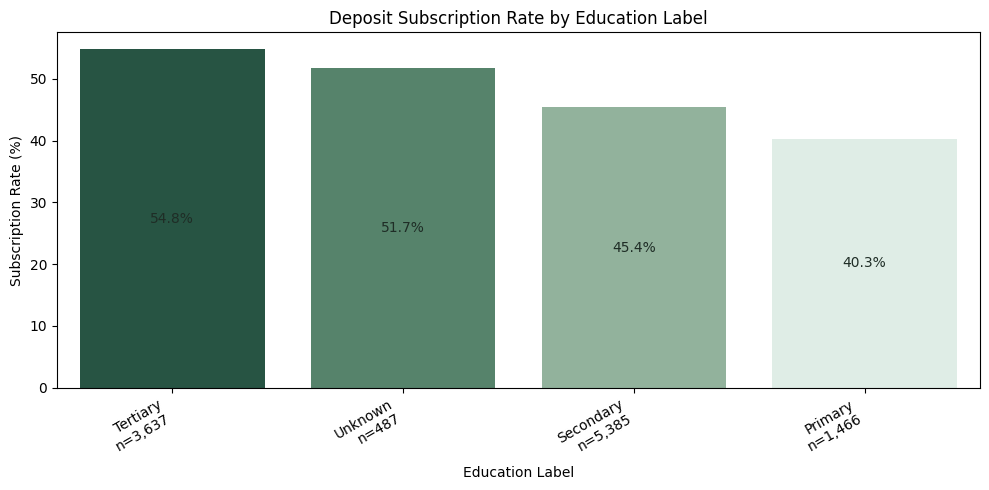

In [53]:
analyze_profile_variable(df, "education_label", sort=True)

Customers with tertiary education consistently achieve the highest subscription rates, whereas secondary education records the lowest conversion. The results suggest a positive association between education level and deposit subscription.

### Marital Status

Marital status is analysed to assess whether customers’ family situation is associated with different subscription rates.

deposit,non_subscription_rate,subscription_rate,n_clients
marital,,,
single,45.0,55.0,3468
divorced,51.3,48.7,1273
married,55.8,44.2,6234


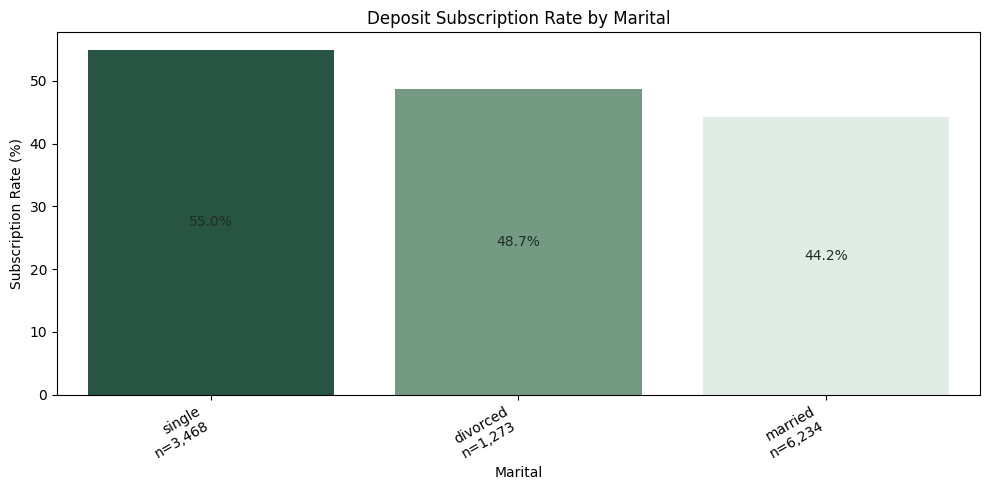

In [54]:
analyze_profile_variable(df, "marital", sort=True)

Single customers show the highest subscription rate, while married customers present the lowest conversion. This suggests that marital status may be associated with different financial priorities and product adoption behaviour.

### Age x Job

Combining demographic variables provides a more detailed customer profile than analysing each characteristic separately. The heatmap highlights the interaction between age and occupation.

In [55]:
summary = (
    df.groupby(["age_group", "job_profile"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={1: "subscription_rate",
                       0: "non_subscription_rate"})
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["age_group", "job_profile"], observed=True)
      .size()
)

display(summary)

deposit                            non_subscription_rate  subscription_rate  \
age_group           job_profile                                               
Adult (36-50)       Blue Collar                     65.1               34.9   
                    Retired                         72.2               27.8   
                    Self-Employed                   62.2               37.8   
                    Student                         36.4               63.6   
                    Unemployed                      46.8               53.2   
                    Unknown                         58.1               41.9   
                    White Collar                    54.1               45.9   
Middle-Aged (51-65) Blue Collar                     62.2               37.8   
                    Retired                         43.1               56.9   
                    Self-Employed                   59.7               40.3   
                    Unemployed                      37.0               63.0   
                    Unknown                         45.5               54.5   
                    White Collar                    49.1               50.9   
Senior (65+)        Blue Collar                     21.4               78.6   
                    Retired                         19.5               80.5   
                    Self-Employed                    NaN              100.0   
                    Unknown                         50.0               50.0   
                    White Collar                    20.8               79.2   
Young (18-25)       Blue Collar                     34.3               65.7   
                    Self-Employed                   21.4               78.6   
                    Student                         19.7               80.3   
                    Unemployed                      16.7               83.3   
                    White Collar                    36.0               64.0   
Young Adult (26-35) Blue Collar                     59.5               40.5   
                    Retired                          NaN              100.0   
                    Self-Employed                   51.4               48.6   
                    Student                         30.1               69.9   
                    Unemployed                      38.9               61.1   
                    Unknown                         46.2               53.8   
                    White Collar                    49.6               50.4   

deposit                            n_clients  
age_group           job_profile               
Adult (36-50)       Blue Collar         1385  
                    Retired               18  
                    Self-Employed        315  
                    Student               22  
                    Unemployed           154  
                    Unknown               31  
                    White Collar        2330  
Middle-Aged (51-65) Blue Collar          490  
                    Retired              401  
                    Self-Employed        139  
                    Unemployed            73  
                    Unknown               22  
                    White Collar         914  
Senior (65+)        Blue Collar           14  
                    Retired              349  
                    Self-Employed          6  
                    Unknown                4  
                    White Collar          24  
Young (18-25)       Blue Collar          105  
                    Self-Employed         14  
                    Student              183  
                    Unemployed             6  
                    White Collar         136  
Young Adult (26-35) Blue Collar         1082  
                    Retired                1  
                    Self-Employed        243  
                    Student              153  
                    Unemployed           113  
                    Unknown               13  
              

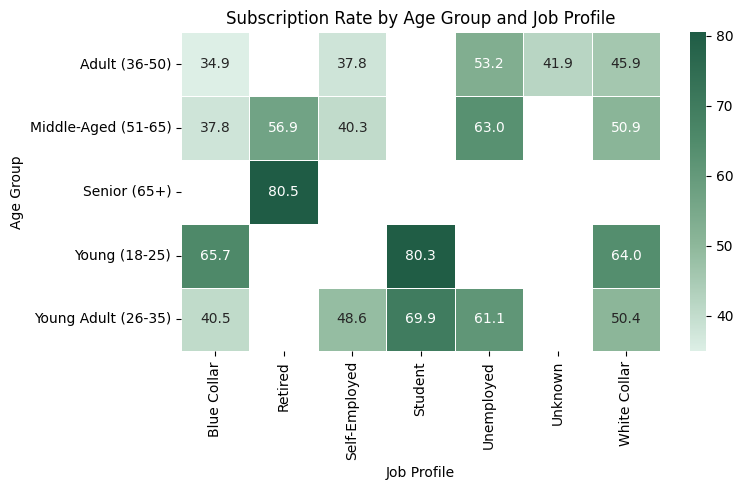

In [56]:
summary_filtered = summary.copy()
summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

heatmap_data = summary_filtered["subscription_rate"].unstack()
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Age Group and Job Profile")
plt.xlabel("Job Profile")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

Students and retired customers consistently present the highest subscription rates, whereas operational occupations remain the weakest-performing group across most age segments. Results from very small groups should be interpreted cautiously. Cells with missing values represent combinations with insufficient observations and were excluded from interpretation.

### Education × Marital

A second multivariate analysis explores whether education and marital status jointly influence subscription behaviour.

In [57]:
summary = (
    df.groupby(["education_label", "marital"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={
          1: "subscription_rate",
          0: "non_subscription_rate"
      })
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["education_label", "marital"], observed=True)
      .size()
)

display(summary)

deposit                   non_subscription_rate  subscription_rate  n_clients
education_label marital                                                      
Primary         divorced                   48.8               51.2        203
                married                    63.0               37.0       1069
                single                     53.1               46.9        194
Secondary       divorced                   54.9               45.1        641
                married                    57.5               42.5       3066
                single                     49.1               50.9       1678
Tertiary        divorced                   46.4               53.6        379
                married                    49.8               50.2       1817
                single                     39.1               60.9       1441
Unknown         divorced                   52.0               48.0         50
                married                    49.6               50.4        282
                single                     44.5               55.5        155

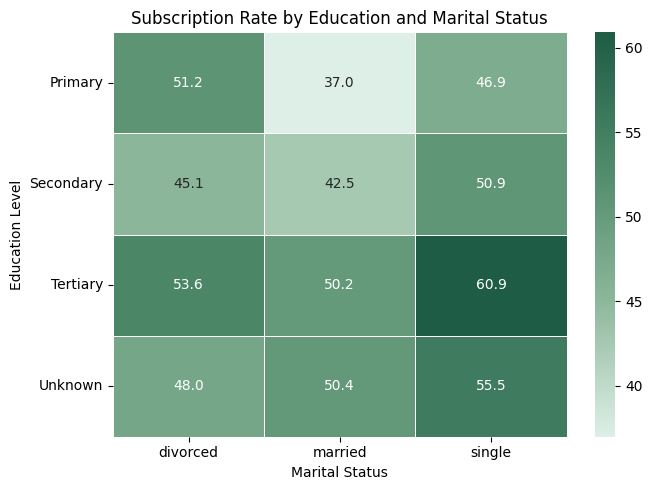

In [58]:
# filter small groups

summary_filtered = summary.copy()

summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

# heatmap

heatmap_data = summary_filtered["subscription_rate"].unstack()

# order

education_order = [
    "Primary",
    "Secondary",
    "Tertiary",
    "Unknown"
]

heatmap_data = heatmap_data.reindex(education_order)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Education and Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Education Level")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Subscription rates tend to increase with higher education levels, especially among single customers. Married customers with primary or secondary education show the lowest conversion rates, while single customers with tertiary education exhibit the highest subscription rate (62.5%).

## Business Conclusions

### Key findings

Older customers, students and retired clients exhibit the highest subscription rates.
Tertiary education is consistently associated with higher conversion.
Multivariate analysis confirms that demographic characteristics interact, producing customer segments with substantially different subscription behaviour.

The analysis indicates that the most favourable customer profile combines higher education, single marital status, and demographic segments such as students or retirees, which consistently achieve the highest subscription rates across the analyses.

### Business implication

Demographic profiling can support more targeted marketing campaigns by identifying customer segments with the highest likelihood of subscribing to a term deposit.

# Clusteritzacions

## Clusteritació amb k-prototiper directa

In [ ]:

# # 2. Seleccionar només variables d'identitat (sense engagement, balance, ni duration/campaign/pdays/previous/poutcome)
# cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
# df_cluster = df[cluster_vars].copy()

# # 3. Escalar age (obligatori per K-Prototypes)
# scaler = StandardScaler()
# df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

# # 4. Preparar la matriu: numèrica primer, categòriques després
# X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values
# categorical_idx = [1, 2, 3]  # posicions de les columnes categòriques dins de X

# # 5. Elbow method (k=2 a 7)
# costs = []
# for k in range(2, 8):
#     kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
#     kproto.fit_predict(X, categorical=categorical_idx)
#     costs.append(kproto.cost_)
#     print(f"k={k} -> cost={kproto.cost_:.1f}")

# # 6. Entrenar model final amb k=4 (a confirmar segons la vostra lectura del colze)
# kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
# df['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)


## Clusteritació amb k-prototiper directa + segments students/retired

In [60]:
# 2. Separar els segments de regla de negoci
df_rest = df[~df['job_profile'].isin(['Student', 'Retired'])].copy()

print(f"Total dataset: {len(df)}")
print(f"Excloent Student i Retired: {len(df_rest)}")
print(df['job_profile'].value_counts())

Total dataset: 10975
Excloent Student i Retired: 9848
job_profile
White Collar     5639
Blue Collar      3076
Retired           769
Self-Employed     717
Student           358
Unemployed        346
Unknown            70
Name: count, dtype: int64


In [ ]:
# 3. Seleccionar variables d'identitat (sense engagementn, balance, ni variables de campanya)
cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
df_cluster = df_rest[cluster_vars].copy()

# 4. Comprovar que no hi ha nulls abans d'escalar/clusteritzar
print(df_cluster.isna().sum())

# 5. Escalar age
scaler = StandardScaler()
df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

print(df_cluster[['age', 'age_scaled']].head())

age                0
job_profile        0
education_label    0
marital            0
dtype: int64
    age  age_scaled
0  59.0    1.964237
1  56.0    1.655520
2  41.0    0.111934
3  55.0    1.552614
4  54.0    1.449708


In [62]:
# 6. Preparar la matriu X: age_scaled primer, després les 3 categòriques
X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values

# 7. Indicar les posicions (índexs de columna dins de X) que són categòriques
categorical_idx = [1, 2, 3]  # job_profile, education_label, marital

print(X.shape)
print(X[:3])  # primeres 3 files, per veure que la matriu té la pinta correcta

(9848, 4)
[[1.964236912718694 'White Collar' 'Secondary' 'married']
 [1.655519760798443 'White Collar' 'Secondary' 'married']
 [0.11193400119718808 'White Collar' 'Secondary' 'married']]


In [63]:
# 8. Elbow method: provar k de 2 a 7
costs = []
for k in range(2, 8):
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
    kproto.fit_predict(X, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f"k={k} -> cost={kproto.cost_:.1f}")

k=2 -> cost=9468.2
k=3 -> cost=7481.9
k=4 -> cost=6439.7
k=5 -> cost=5777.7
k=6 -> cost=5484.2
k=7 -> cost=5042.7


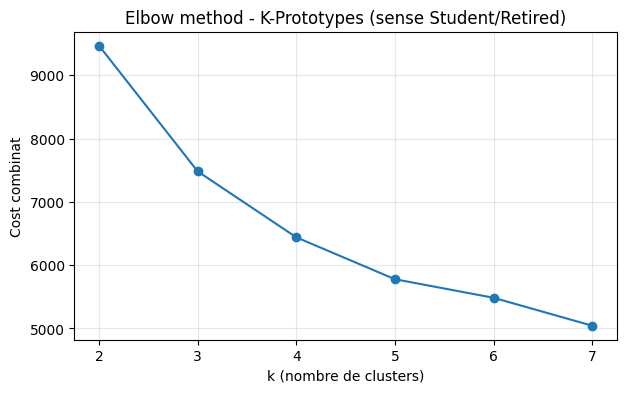

In [64]:

k_range = range(2, 8)
plt.figure(figsize=(7,4))
plt.plot(k_range, costs, marker='o')
plt.xlabel('k (nombre de clusters)')
plt.ylabel('Cost combinat')
plt.title('Elbow method - K-Prototypes (sense Student/Retired)')
plt.grid(True, alpha=0.3)
plt.show()

In [65]:
# 9. Model final amb k=4
kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
df_rest['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)

print("Cost final:", kproto_final.cost_)
print(df_rest['cluster'].value_counts().sort_index())

Cost final: 6439.747077084839
cluster
0    2645
1    2292
2    2210
3    2701
Name: count, dtype: int64


In [66]:
# 10. Caracterització de cada cluster
for c in sorted(df_rest['cluster'].unique()):
    sub = df_rest[df_rest['cluster']==c]
    print(f"--- Cluster {c} (n={len(sub)}, {len(sub)/len(df_rest)*100:.1f}%) ---")
    print("age mean:", round(sub['age'].mean(),1), "| age median:", sub['age'].median())
    print("job_profile:", sub['job_profile'].value_counts(normalize=True).round(3).to_dict())
    print("education_label:", sub['education_label'].value_counts(normalize=True).round(3).to_dict())
    print("marital:", sub['marital'].value_counts(normalize=True).round(3).to_dict())
    print()

--- Cluster 0 (n=2645, 26.9%) ---
age mean: 53.0 | age median: 52.0
job_profile: {'White Collar': 0.594, 'Blue Collar': 0.271, 'Self-Employed': 0.081, 'Unemployed': 0.04, 'Unknown': 0.013}
education_label: {'Secondary': 0.472, 'Tertiary': 0.284, 'Primary': 0.179, 'Unknown': 0.065}
marital: {'married': 0.74, 'divorced': 0.175, 'single': 0.085}

--- Cluster 1 (n=2292, 23.3%) ---
age mean: 39.4 | age median: 40.0
job_profile: {'Blue Collar': 0.709, 'White Collar': 0.175, 'Self-Employed': 0.068, 'Unemployed': 0.04, 'Unknown': 0.007}
education_label: {'Secondary': 0.729, 'Primary': 0.221, 'Unknown': 0.039, 'Tertiary': 0.011}
marital: {'married': 0.743, 'single': 0.133, 'divorced': 0.124}

--- Cluster 2 (n=2210, 22.4%) ---
age mean: 37.1 | age median: 37.0
job_profile: {'White Collar': 0.865, 'Self-Employed': 0.089, 'Unemployed': 0.025, 'Blue Collar': 0.018, 'Unknown': 0.004}
education_label: {'Tertiary': 0.811, 'Secondary': 0.127, 'Primary': 0.032, 'Unknown': 0.03}
marital: {'married': 0.68

In [67]:
# 11. Construir la columna 'segment' final combinant regla de negoci + clusters
df['segment'] = None
df.loc[df['job_profile']=='Student', 'segment'] = 'Student'
df.loc[df['job_profile']=='Retired', 'segment'] = 'Retired'

# Mapejar els clusters de df_rest cap a df original, usant el seu índex
df.loc[df_rest.index, 'segment'] = df_rest['cluster'].apply(lambda c: f'Cluster_{c}')

print(df['segment'].value_counts())
print()
print("Total assignat:", df['segment'].notna().sum(), "de", len(df))

segment
Cluster_3    2701
Cluster_0    2645
Cluster_1    2292
Cluster_2    2210
Retired       769
Student       358
Name: count, dtype: int64

Total assignat: 10975 de 10975


In [68]:
# Nom descriptiu de treball (provisional, pendent de validar amb Pas 2 i amb l'Elisa)
label_map = {
    'Cluster_0': 'Adultos consolidados',
    'Cluster_1': 'Trabajadores técnicos',
    'Cluster_2': 'Professionales estudios superiores',
    'Cluster_3': 'Jovenes en consolidación',
    'Retired': 'Jubilados',
    'Student': 'Estudiantes'
}
df['segment_label'] = df['segment'].map(label_map)

print(df[['segment','segment_label']].drop_duplicates())

       segment                       segment_label
0    Cluster_0                Adultos consolidados
2    Cluster_1               Trabajadores técnicos
5    Cluster_2  Professionales estudios superiores
7      Retired                           Jubilados
9    Cluster_3            Jovenes en consolidación
162    Student                         Estudiantes


In [69]:
df.to_csv('../Data/2026-07-06_4_bank_dataset_clustered.csv', index=False)
print(df[['segment','segment_label']].drop_duplicates())

       segment                       segment_label
0    Cluster_0                Adultos consolidados
2    Cluster_1               Trabajadores técnicos
5    Cluster_2  Professionales estudios superiores
7      Retired                           Jubilados
9    Cluster_3            Jovenes en consolidación
162    Student                         Estudiantes


### Distribución segmentos

In [98]:
orden_segmentos = df["segment_label"].value_counts().index

segmentos = (
    df["segment_label"]
    .value_counts()
    .rename_axis("Segmento")
    .reset_index(name="Clientes")
)

segmentos["Porcentaje (%)"] = (
    segmentos["Clientes"] / segmentos["Clientes"].sum() * 100
).round(1)

segmentos["Etiqueta"] = [
    f"{textwrap.fill(str(seg), width=16)}\nn={n:,}".replace(",", ".")
    for seg, n in zip(segmentos["Segmento"], segmentos["Clientes"])
]

display(segmentos)

colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

palette = sns.blend_palette(
    colors,
    n_colors=segmentos.shape[0]
)

,Segmento,Clientes,Porcentaje (%),Etiqueta
0,Jovenes en consolidación,2701,24.6,Jovenes en\nconsolidación\nn=2.701
1,Adultos consolidados,2645,24.1,Adultos\nconsolidados\nn=2.645
2,Trabajadores técnicos,2292,20.9,Trabajadores\ntécnicos\nn=2.292
3,Professionales estudios superiores,2210,20.1,Professionales\nestudios\nsuperiores\nn=2.210
4,Jubilados,769,7.0,Jubilados\nn=769
5,Estudiantes,358,3.3,Estudiantes\nn=358


# Estudio perfiles semana 2

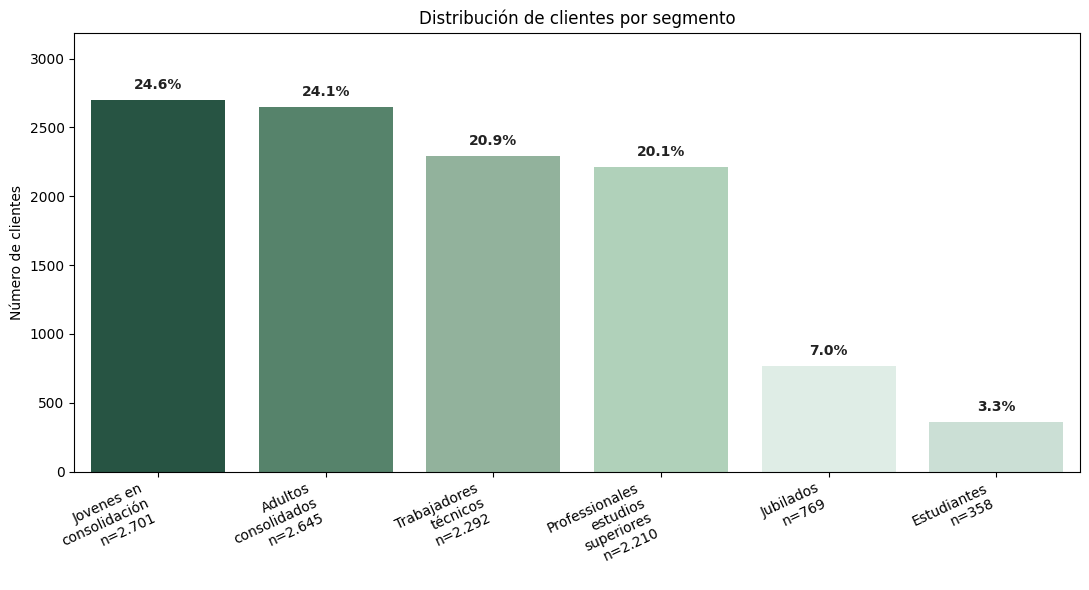

In [99]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segmentos,
    x="Etiqueta",
    y="Clientes",
    hue="Etiqueta",
    palette=palette,
    legend=False
)

plt.title("Distribución de clientes por segmento")
plt.xlabel("")
plt.ylabel("Número de clientes")
plt.xticks(rotation=25, ha="right")

# Etiquetas encima de las barras
for i, row in segmentos.set_index("Segmento").loc[orden_segmentos].reset_index().iterrows():
    ax.text(
        i,
        row["Clientes"] + 60,
        f'{row["Porcentaje (%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

# Dar espacio arriba para que las etiquetas no se corten
ax.set_ylim(0, segmentos["Clientes"].max() * 1.18)

plt.tight_layout()
plt.show()

La distribución de clientes por segmento muestra cuatro grupos principales con tamaños similares, entre el 20,1 % y el 24,6 % del total. Los segmentos de jubilados y estudiantes son más pequeños, pero se mantienen separados por su comportamiento diferencial observado previamente. Esta distribución permite comparar el comportamiento financiero entre perfiles sin que un único segmento domine el análisis.

### Analisis variables financieras

In [104]:
# función reutilizable numeric

def analyze_numeric_by_segment(df, variable, segment_col="segment_label"):
    """
    Analiza una variable numérica por segmento.
    Genera una tabla resumen y un gráfico de barras con la mediana.
    """

    summary = (
        df.groupby(segment_col, observed=True)[variable]
          .agg(
              n_clients="count",
              mean="mean",
              median="median",
              std="std",
              min="min",
              max="max"
          )
          .round(2)
          .sort_values("median", ascending=False)
    )

    display(summary)

    summary["label"] = [
    f"{textwrap.fill(str(segment), width=16)}\nn={n:,}".replace(",", ".")
    for segment, n in zip(summary.index, summary["n_clients"])
]

    colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plot_data = summary.reset_index()

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=plot_data,
        x="label",
        y="median",
        hue="label",
        palette=palette,
        legend=False,
        width=0.8,
        dodge=False
    )

    for index, row in plot_data.iterrows():
        ax.text(
            x=index,
            y=row["median"] + (plot_data["median"].max() * 0.03),
            s=f'{row["median"]:,.0f} €'.replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=10,
            color="#1F2D26",
            fontweight="bold"
        )

    plt.title(f"Mediana de {variable.replace('_', ' ').title()} por segmento")
    plt.xlabel("Segmento")
    plt.ylabel(f"Mediana de {variable}")
    plt.xticks(rotation=45, ha="right")

    plt.ylim(0, plot_data["median"].max() * 1.18)

    plt.tight_layout()
    plt.show()

In [101]:
# función reutilizable categoric

def analyze_categorical_by_segment(
    df,
    variable,
    segment_col="segment_label",
    order=None,
    highlight_value="yes",
    sort_by_highlight=True,
    x_limit=None
):
    counts = pd.crosstab(df[segment_col], df[variable])

    percentages = (
        pd.crosstab(df[segment_col], df[variable], normalize="index")
        .mul(100)
        .round(1)
    )

    if order is not None:
        counts = counts.reindex(columns=order, fill_value=0)
        percentages = percentages.reindex(columns=order, fill_value=0)

    if highlight_value not in percentages.columns:
        raise ValueError(
            f"'{highlight_value}' is not present in {variable}. "
            f"Available values: {list(percentages.columns)}"
        )

    segment_n = counts.sum(axis=1)

    summary = percentages.copy()
    summary["n_clients"] = segment_n

    display(summary)

    plot_data = pd.DataFrame({
        "segment": percentages.index,
        "highlight_rate": percentages[highlight_value],
        "n_clients": segment_n
    })

    plot_data["label"] = [
    f"{textwrap.fill(str(segment), width=16)}\nn={n:,}".replace(",", ".")
    for segment, n in zip(plot_data["segment"], plot_data["n_clients"])
]

    if sort_by_highlight:
        plot_data = plot_data.sort_values(
            by="highlight_rate",
            ascending=False
        )

    label_order = plot_data["label"].tolist()

    fig_height = max(4.5, 0.65 * len(plot_data))

    plt.figure(figsize=(10, fig_height))

    ax = sns.barplot(
        data=plot_data,
        x="highlight_rate",
        y="label",
        order=label_order,
        color="#4F8A6A"
    )

    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2

        ax.text(
            x=width + 0.6,
            y=y,
            s=f"{width:.1f}%",
            va="center",
            ha="left",
            fontsize=11,
            fontweight="bold",
            color="#1F2D26"
        )

    max_rate = plot_data["highlight_rate"].max()

    if x_limit is None:
        x_limit = min(100, max_rate + 8)

    plt.xlim(0, x_limit)

    highlight_label = str(highlight_value).replace("_", " ").title()
    variable_label = variable.replace("_", " ").title()

    plt.title(f"{highlight_label} Rate in {variable_label} by Segment")
    plt.xlabel("Percentage (%)")
    plt.ylabel("Segment")

    ax.grid(False)
    sns.despine(left=True, bottom=False)

    plt.tight_layout()
    plt.show()

#### Balance

,n_clients,mean,median,std,min,max
segment_label,,,,,,
Jubilados,769,2427.64,1097.0,5424.85,-1206,81204
Adultos consolidados,2645,1781.78,644.0,3674.44,-6847,66653
Professionales estudios superiores,2210,1639.76,587.0,3193.12,-3058,45248
Estudiantes,358,1508.10,497.5,2663.93,0,23878
Trabajadores técnicos,2292,1198.88,461.5,2401.56,-1701,56831
Jovenes en consolidación,2701,1259.13,458.0,2543.66,-1139,36252


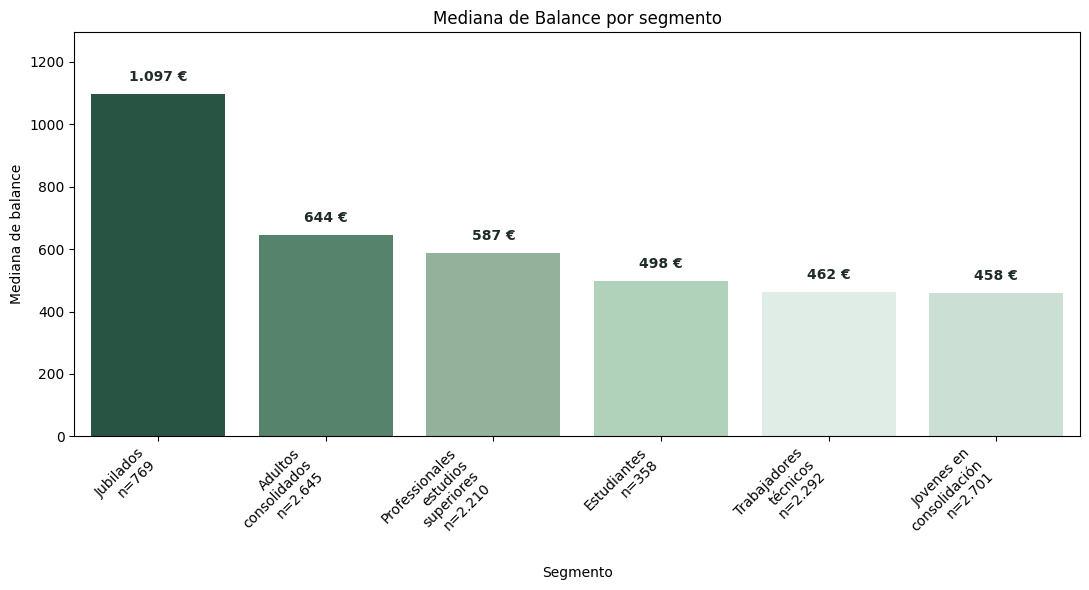

In [105]:
analyze_numeric_by_segment(df, "balance")

Los jubilados presentan la mayor mediana de saldo, mientras que los jóvenes solteros y los trabajadores manuales muestran los niveles más bajos. La diferencia entre medias y medianas confirma una fuerte asimetría provocada por un número reducido de clientes con saldos muy elevados.

In [106]:
#### Housing

housing,no,yes,n_clients
segment_label,,,
Adultos consolidados,60.7,39.3,2645
Estudiantes,85.8,14.2,358
Jovenes en consolidación,48.5,51.5,2701
Jubilados,84.4,15.6,769
Professionales estudios superiores,52.4,47.6,2210
Trabajadores técnicos,33.4,66.6,2292


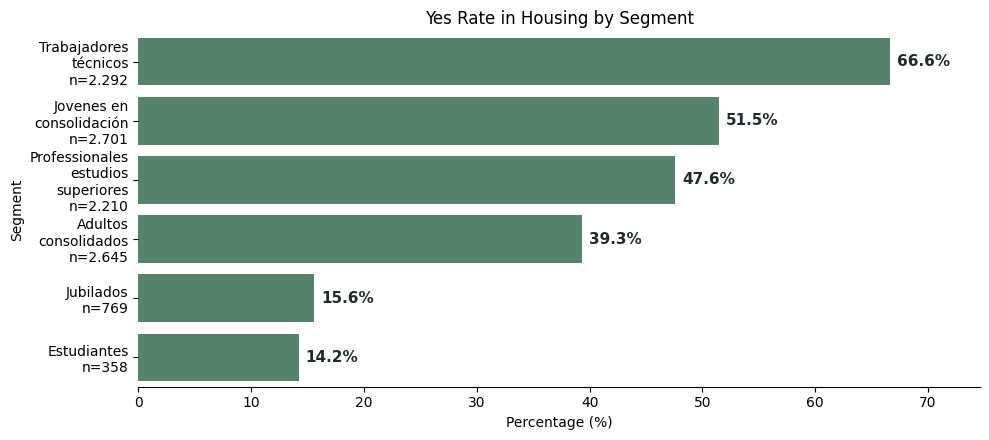

In [107]:
analyze_categorical_by_segment(df, "housing", order=["no", "yes"], highlight_value="yes")

Los trabajadores manuales son el segmento con mayor proporción de hipotecas, seguidos por los jóvenes solteros. En cambio, estudiantes y jubilados apenas presentan financiación hipotecaria, lo que refleja perfiles financieros claramente diferenciados.

#### Loan

loan,no,yes,n_clients
segment_label,,,
Adultos consolidados,85.7,14.3,2645
Estudiantes,99.7,0.3,358
Jovenes en consolidación,86.9,13.1,2701
Jubilados,93.0,7.0,769
Professionales estudios superiores,88.3,11.7,2210
Trabajadores técnicos,83.3,16.7,2292


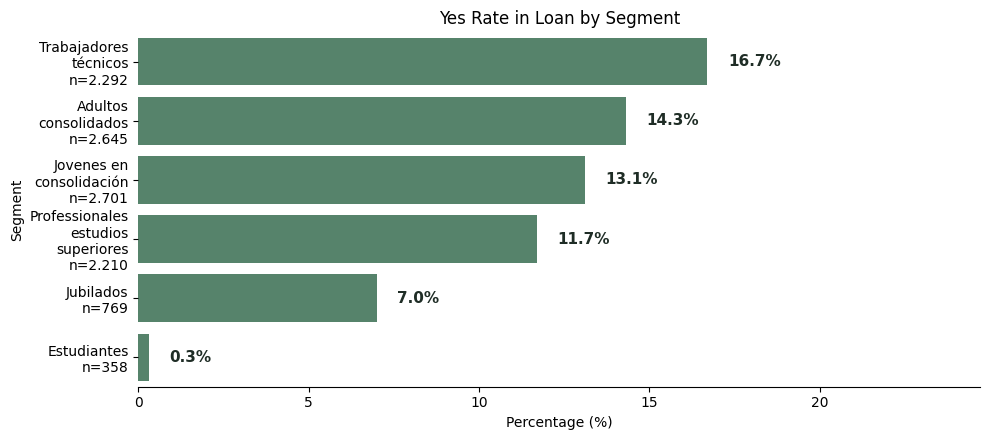

In [108]:
analyze_categorical_by_segment(df, "loan", order=["no", "yes"], highlight_value="yes")

El préstamo personal es poco frecuente en todos los segmentos. Los trabajadores manuales concentran la mayor proporción de clientes con este producto, mientras que los estudiantes prácticamente no recurren a este tipo de financiación.

#### Engagement

engagement_label,High engagement,Low engagement,Medium engagement,n_clients
segment_label,,,,
Adultos consolidados,6.8,53.3,39.8,2645
Estudiantes,0.0,85.5,14.5,358
Jovenes en consolidación,6.9,42.3,50.8,2701
Jubilados,2.9,80.2,16.9,769
Professionales estudios superiores,7.2,47.9,44.8,2210
Trabajadores técnicos,11.7,28.4,59.9,2292


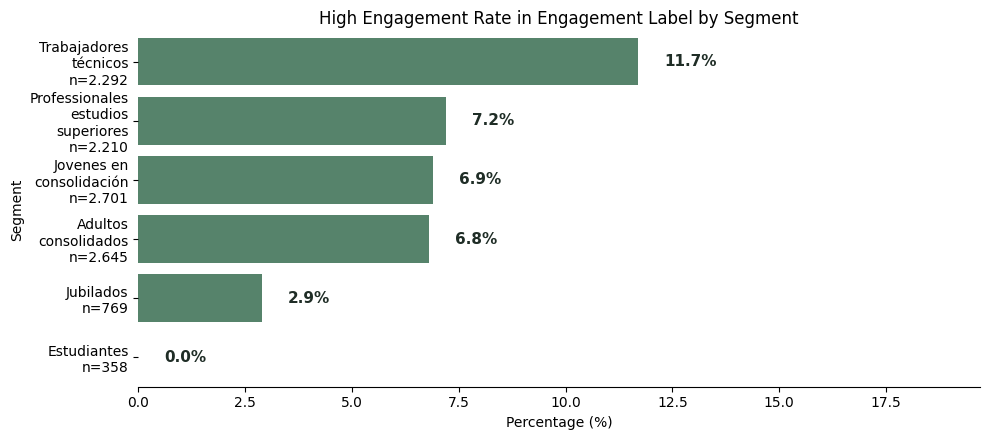

In [109]:
analyze_categorical_by_segment(df, "engagement_label", highlight_value="High engagement")

La carga financiera varía notablemente entre segmentos. Los trabajadores manuales presentan la mayor proporción de clientes con carga financiera alta o moderada, mientras que jubilados y estudiantes se concentran principalmente en situaciones de baja o nula carga financiera.

nueva conclusion:
El nivel de engagement varía notablemente entre segmentos. Los trabajadores técnicos presentan la mayor proporción de clientes con alto engagement (11,7%), seguidos de un bloque intermedio bastante homogéneo (profesionales con estudios superiores, jóvenes en consolidación y adultos consolidados, entre el 6,8% y el 7,2%). Jubilados (2,9%) y, especialmente, estudiantes (0,0%) presentan los niveles de engagement más bajos, lo que indica que apenas tienen productos de crédito contratados con la entidad más allá de la cuenta base.

Esta variable debe interpretarse en sentido opuesto a como se interpretaba bajo el concepto anterior de "carga financiera": un alto engagement no representa un riesgo, sino un vínculo comercial más profundo con el cliente. Bajo esta óptica, jubilados y estudiantes no son segmentos "sanos" por tener poca exposición, sino segmentos con mayor margen de venta cruzada, ya que actualmente mantienen muy pocos productos contratados.

#### Default

default,no,yes,n_clients
segment_label,,,
Adultos consolidados,98.4,1.6,2645
Estudiantes,99.7,0.3,358
Jovenes en consolidación,98.3,1.7,2701
Jubilados,99.3,0.7,769
Professionales estudios superiores,98.7,1.3,2210
Trabajadores técnicos,98.3,1.7,2292


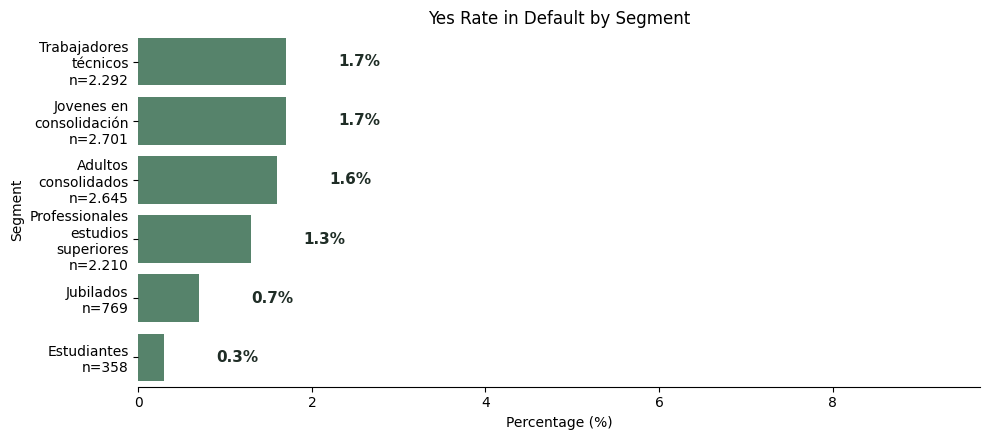

In [110]:
analyze_categorical_by_segment(df, "default", order=["no", "yes"], highlight_value="yes")

El porcentaje de clientes en situación de impago es muy reducido en todos los segmentos y las diferencias observadas son mínimas. Esta variable no parece aportar capacidad de diferenciación entre los perfiles demográficos identificados.

### Resumen del perfil financiero por segmento

In [111]:
perfil = (
    df.groupby("segment_label", observed=True)
      .agg(
          Clientes=("id", "count"),
          Balance_mediana=("balance", "median"),
          Hipoteca_pct=("housing", lambda x: (x == "yes").mean() * 100),
          Prestamo_personal_pct=("loan", lambda x: (x == "yes").mean() * 100),
          Engagement_alto_pct=("engagement_label", lambda x: (x == "High engagement").mean() * 100),
          Engagement_bajo_pct=("engagement_label", lambda x: (x == "Low engagement").mean() * 100),
          Default_pct=("default", lambda x: (x == "yes").mean() * 100)
      )
      .round(1)
)

perfil = perfil.rename(columns={
    "Balance_mediana": "Mediana balance (€)",
    "Hipoteca_pct": "Hipoteca (%)",
    "Prestamo_personal_pct": "Préstamo personal (%)",
    "Engagement_alto_pct": "Engagement alto (%)",
    "Engagement_bajo_pct": "Engagement bajo (%)",
    "Default_pct": "Default (%)"
})

display(perfil)

,Clientes,Mediana balance (€),Hipoteca (%),Préstamo personal (%),Engagement alto (%),Engagement bajo (%),Default (%)
segment_label,,,,,,,
Adultos consolidados,2645,644.0,39.3,14.3,6.8,53.3,1.6
Estudiantes,358,497.5,14.2,0.3,0.0,85.5,0.3
Jovenes en consolidación,2701,458.0,51.5,13.1,6.9,42.3,1.7
Jubilados,769,1097.0,15.6,7.0,2.9,80.2,0.7
Professionales estudios superiores,2210,587.0,47.6,11.7,7.2,47.9,1.3
Trabajadores técnicos,2292,461.5,66.6,16.7,11.7,28.4,1.7


- Jubilados presentan el perfil financiero más sólido: tienen la mediana de balance más alta y bajos niveles de endeudamiento (hipoteca, préstamo personal y carga financiera alta)
- Trabajadores manuales muestran la mayor exposición financiera del conjunto. Son el segmento con mayor porcentaje de hipotecas, préstamos personales y carga financiera alta, además de presentar el balance mediano más bajo
- Profesionales con estudios superiores mantienen un balance relativamente elevado, aunque una proporción importante dispone de hipoteca. Su nivel de carga financiera se sitúa en valores intermedios
- Adultos consolidados presentan un perfil equilibrado, con un balance superior a la media de la mayoría de segmentos y niveles moderados de financiación
- Jóvenes solteros poseen el menor patrimonio (mediana de balance) pero una elevada presencia de hipotecas, lo que sugiere una etapa inicial de consolidación financiera
- Estudiantes destacan por una exposición financiera prácticamente nula: muy pocos tienen hipoteca o préstamo personal y no se observan casos con carga financiera alta
- Default registra valores muy bajos en todos los segmentos (inferiores al 2 %), por lo que no parece ser una variable que diferencie claramente los perfiles financieros


nueva interpretacion:
El nivel de engagement varía notablemente entre segmentos, y la lectura es opuesta según el extremo de la distribución que se observe:

- **Trabajadores técnicos** presenta el mayor engagement alto (11,7%) y el menor engagement bajo (28,4%) — es el segmento más vinculado a la entidad en términos de productos contratados.
- **Estudiantes** (85,5% bajo engagement) y **Jubilados** (80,2% bajo engagement) son los segmentos con menor vinculación actual, lo que representa el mayor margen de oportunidad para venta cruzada, no un signo de solidez financiera per se.
- El resto de segmentos (Adultos consolidados, Jóvenes en consolidación, Profesionales con estudios superiores) se sitúan en una franja intermedia, con engagement bajo entre el 42% y el 53%.

A diferencia del enfoque anterior (carga financiera), donde un valor alto era una señal de alerta, aquí un valor alto de engagement indica una relación comercial más profunda con el cliente. El foco de negocio se desplaza: en lugar de identificar segmentos "en riesgo", el objetivo es identificar segmentos con margen de crecimiento (bajo engagement) sobre los que dirigir estrategias de vinculación.

In [113]:
df.groupby(["segment_label", "engagement_label"])["balance"].agg(
    clients="count",
    median_balance="median",
    mean_balance="mean"
).round(1)

clients  median_balance  \
segment_label                      engagement_label                             
Adultos consolidados               High engagement        181           371.0   
                                   Low engagement        1410           790.0   
                                   Medium engagement     1054           589.0   
Estudiantes                        Low engagement         306           480.0   
                                   Medium engagement       52           575.5   
Jovenes en consolidación           High engagement        187           218.0   
                                   Low engagement        1143           590.0   
                                   Medium engagement     1371           399.0   
Jubilados                          High engagement         22          1269.5   
                                   Low engagement         617          1255.0   
                                   Medium engagement      130           520.5   
Professionales estudios superiores High engagement        160           398.5   
                                   Low engagement        1059           687.0   
                                   Medium engagement      991           488.0   
Trabajadores técnicos              High engagement        268           292.0   
                                   Low engagement         650           634.0   
                                   Medium engagement     1374           454.5   

                                                      mean_balance  
segment_label                      engagement_label                 
Adultos consolidados               High engagement          1080.0  
                                   Low engagement           2004.1  
                                   Medium engagement        1604.9  
Estudiantes                        Low engagement           1495.1  
                                   Medium engagement        1584.9  
Jovenes en consolidación           High engagement           561.9  
                                   Low engagement           1559.9  
                                   Medium engagement        1103.5  
Jubilados                          High engagement          1696.8  
                                   Low engagement           2588.8  
                                   Medium engagement        1786.6  
Professionales estudios superiores High engagement           868.3  
                                   Low engagement           1921.2  
                                   Medium engagement        1463.5  
Trabajadores técnicos              High engagement           579.6  
                                   Low engagement           1606.0  
                                   Medium engagement        1127.1

La carga financiera parece asociarse con menor liquidez en casi todos los segmentos. Esto ayuda a personalizar ofertas (jóvenes solteros / treballadors manuals con alta carga financiera tienen una mediana de balance muy baja. Perfil tensionado?)

nuevo:
Dentro de cada segmento, el engagement bajo se asocia sistemáticamente con una mediana de balance más alta, y el engagement alto con balances más bajos. Este patrón es coherente con la lógica de vinculación: los clientes con más productos de crédito contratados (mayor engagement) destinan una parte de su liquidez a esos compromisos, mientras que los de bajo engagement conservan más saldo disponible.

Esto ayuda a personalizar ofertas: los segmentos con bajo engagement y alta liquidez (como jubilados y estudiantes) son los mejores candidatos para productos de ahorro o vinculación inicial, mientras que los de alto engagement ya mantienen una relación comercial más profunda y podrían orientarse hacia productos de optimización o consolidación de lo ya contratado.

In [114]:
pd.crosstab(
    df["segment_label"],
    [df["housing"], df["loan"]],
    normalize="index"
).mul(100).round(1)

housing                               no        yes      
loan                                  no  yes    no   yes
segment_label                                            
Adultos consolidados                53.3  7.4  32.4   6.8
Estudiantes                         85.5  0.3  14.2   0.0
Jovenes en consolidación            42.3  6.1  44.6   6.9
Jubilados                           80.2  4.2  12.7   2.9
Professionales estudios superiores  47.9  4.5  40.4   7.2
Trabajadores técnicos               28.4  5.0  54.9  11.7

11,7% de trabajadores manuales tienen simultáneamente hipoteca y préstamo personal. Es el porcentaje más alto de todos los segmentos. Joves solters 6.9 yes/yes y mediana de deposito baja.

Los perfiles con alta liquidez y baja carga pueden recibir ofertas de ahorro o inversión, mientras que perfiles con baja liquidez y alta exposición deberían recibir propuestas más prudentes

nuevo:
El 11,7% de trabajadores técnicos tiene simultáneamente hipoteca y préstamo personal — el porcentaje más alto de todos los segmentos, coherente con ser el segmento de mayor engagement. Jóvenes en consolidación presenta un 6,9% con ambos productos, combinado con una mediana de balance baja.

Los perfiles con alta liquidez y bajo engagement (jubilados, estudiantes) son los mejores candidatos para ofertas de ahorro, inversión o vinculación inicial, mientras que los de alto engagement (trabajadores técnicos) ya mantienen una relación comercial consolidada y encajan mejor con productos de fidelización u optimización de lo ya contratado, en lugar de nueva financiación.

## Validación estadistica variables categóricas
- Chi-cuadrado (housing)
- Chi-cuadrado (loan)
- Chi-cuadrado (engagement)
- Chi-cuadrado (default)

In [115]:
def chi_cuadrado_por_segmento(df, variable, segmento="segment_label"):
    """
    Aplica la prueba de chi-cuadrado entre una variable categórica
    y los segmentos de clientes.
    """

    tabla = pd.crosstab(df[segmento], df[variable])

    chi2, p_value, dof, expected = chi2_contingency(tabla)

    expected_df = pd.DataFrame(
        expected,
        index=tabla.index,
        columns=tabla.columns
    ).round(2)

    print(f"Variable analizada: {variable}")
    print(f"Chi-cuadrado: {chi2:.4f}")
    print(f"p-value: {p_value:.5f}")
    print(f"Grados de libertad: {dof}")

    print("\nTabla de contingencia")
    display(tabla)

    print("\nFrecuencias esperadas")
    display(expected_df)

    if (expected_df < 5).any().any():
        print("\nAtención: hay frecuencias esperadas menores que 5. El resultado debe interpretarse con cautela.")
    else:
        print("\nSupuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.")

    if p_value < 0.05:
        print("Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.")
    else:
        print("Conclusión: no se observa una asociación estadísticamente significativa entre la variable y el segmento.")

    print("-" * 80)

In [116]:
# Housing

chi_cuadrado_por_segmento(df, "housing")

Variable analizada: housing
Chi-cuadrado: 898.0426
p-value: 0.00000
Grados de libertad: 5

Tabla de contingencia


housing,no,yes
segment_label,,
Adultos consolidados,1606,1039
Estudiantes,307,51
Jovenes en consolidación,1309,1392
Jubilados,649,120
Professionales estudios superiores,1158,1052
Trabajadores técnicos,765,1527



Frecuencias esperadas


housing,no,yes
segment_label,,
Adultos consolidados,1396.37,1248.63
Estudiantes,189.00,169.00
Jovenes en consolidación,1425.93,1275.07
Jubilados,405.98,363.02
Professionales estudios superiores,1166.72,1043.28
Trabajadores técnicos,1210.01,1081.99



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


Existe una asociación muy fuerte entre el segmento demográfico y la posesión de hipoteca. Algunos segmentos presentan una proporción de hipotecas muy superior a la esperada, mientras que otros se sitúan claramente por debajo, indicando que esta variable diferencia bien los perfiles de clientes.

In [117]:
# Loan

chi_cuadrado_por_segmento(df, "loan")

Variable analizada: loan
Chi-cuadrado: 110.2879
p-value: 0.00000
Grados de libertad: 5

Tabla de contingencia


loan,no,yes
segment_label,,
Adultos consolidados,2268,377
Estudiantes,357,1
Jovenes en consolidación,2348,353
Jubilados,715,54
Professionales estudios superiores,1951,259
Trabajadores técnicos,1909,383



Frecuencias esperadas


loan,no,yes
segment_label,,
Adultos consolidados,2301.09,343.91
Estudiantes,311.45,46.55
Jovenes en consolidación,2349.81,351.19
Jubilados,669.01,99.99
Professionales estudios superiores,1922.65,287.35
Trabajadores técnicos,1993.99,298.01



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


Asociación significativa entre el segmento y la contratación de préstamos personales. Aunque las diferencias son menores que en el caso de las hipotecas, determinados segmentos muestran una mayor predisposición a disponer de este producto financiero.

# Engagement


In [119]:

chi_cuadrado_por_segmento(df, "engagement_label")

Variable analizada: engagement_label
Chi-cuadrado: 957.2597
p-value: 0.00000
Grados de libertad: 10

Tabla de contingencia


engagement_label,High engagement,Low engagement,Medium engagement
segment_label,,,
Adultos consolidados,181,1410,1054
Estudiantes,0,306,52
Jovenes en consolidación,187,1143,1371
Jubilados,22,617,130
Professionales estudios superiores,160,1059,991
Trabajadores técnicos,268,650,1374



Frecuencias esperadas


engagement_label,High engagement,Low engagement,Medium engagement
segment_label,,,
Adultos consolidados,197.14,1249.60,1198.26
Estudiantes,26.68,169.13,162.18
Jovenes en consolidación,201.31,1276.05,1223.63
Jubilados,57.32,363.30,348.38
Professionales estudios superiores,164.72,1044.09,1001.20
Trabajadores técnicos,170.83,1082.83,1038.34



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


La carga financiera presenta la asociación más intensa con la segmentación demográfica. Los distintos segmentos muestran distribuciones claramente diferentes entre baja, media y alta carga financiera, lo que confirma que el comportamiento financiero varía considerablemente según el perfil del cliente.

nuevo:
El nivel de engagement presenta la asociación más intensa con la segmentación demográfica de todas las variables analizadas hasta ahora (chi-cuadrado más alto, 957,26). Los distintos segmentos muestran distribuciones claramente diferentes entre bajo, medio y alto engagement, lo que confirma que el grado de vinculación con la entidad varía considerablemente según el perfil del cliente.

Trabajadores técnicos concentra muy por encima de lo esperado los clientes de alto engagement (268 frente a 170,83 esperados), consistente con ser el segmento con mayor penetración de hipoteca y préstamo personal. En el extremo opuesto, estudiantes no registra ningún cliente de alto engagement (0 frente a 26,68 esperados) y concentra muchos más de los esperados en bajo engagement (306 frente a 169,13), mientras que jubilados también se sitúa muy por debajo de lo esperado en alto y medio engagement, con clara sobrerrepresentación en bajo engagement (617 frente a 363,30 esperados).

Esta variable resulta clave para priorizar la estrategia comercial: identifica con precisión qué segmentos ya mantienen una relación profunda con la entidad (trabajadores técnicos) frente a los que representan la mayor oportunidad de vinculación inicial (estudiantes, jubilados).

In [121]:
# Default

chi_cuadrado_por_segmento(df, "default")

Variable analizada: default
Chi-cuadrado: 9.1887
p-value: 0.10177
Grados de libertad: 5

Tabla de contingencia


default,no,yes
segment_label,,
Adultos consolidados,2602,43
Estudiantes,357,1
Jovenes en consolidación,2656,45
Jubilados,764,5
Professionales estudios superiores,2181,29
Trabajadores técnicos,2254,38



Frecuencias esperadas


default,no,yes
segment_label,,
Adultos consolidados,2606.20,38.80
Estudiantes,352.75,5.25
Jovenes en consolidación,2661.38,39.62
Jubilados,757.72,11.28
Professionales estudios superiores,2177.58,32.42
Trabajadores técnicos,2258.38,33.62



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: no se observa una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


No se observa una relación estadísticamente significativa entre el segmento demográfico y el impago de créditos. Aunque existen pequeñas diferencias porcentuales entre segmentos, estas son compatibles con la variabilidad esperada por azar y no permiten concluir que el riesgo de default dependa del perfil demográfico.
- Housing y engagement son las variables que más diferencian los segmentos
- Loan también diferencia los segmentos, pero en menor medida
- Default prácticamente no aporta diferenciación entre segmentos

## Housing + Loan

In [122]:
df["credit_combination"] = (
    "housing_" + df["housing"].astype(str)
    + "_loan_" + df["loan"].astype(str)
)

chi_cuadrado_por_segmento(df, "credit_combination")

Variable analizada: credit_combination
Chi-cuadrado: 1030.7012
p-value: 0.00000
Grados de libertad: 15

Tabla de contingencia


credit_combination,housing_no_loan_no,housing_no_loan_yes,housing_yes_loan_no,housing_yes_loan_yes
segment_label,,,,
Adultos consolidados,1410,196,858,181
Estudiantes,306,1,51,0
Jovenes en consolidación,1143,166,1205,187
Jubilados,617,32,98,22
Professionales estudios superiores,1059,99,892,160
Trabajadores técnicos,650,115,1259,268



Frecuencias esperadas


credit_combination,housing_no_loan_no,housing_no_loan_yes,housing_yes_loan_no,housing_yes_loan_yes
segment_label,,,,
Adultos consolidados,1249.60,146.77,1051.49,197.14
Estudiantes,169.13,19.87,142.32,26.68
Jovenes en consolidación,1276.05,149.88,1073.76,201.31
Jubilados,363.30,42.67,305.71,57.32
Professionales estudios superiores,1044.09,122.63,878.56,164.72
Trabajadores técnicos,1082.83,127.18,911.16,170.83



Supuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.
Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.
--------------------------------------------------------------------------------


- Treballadors manuals destacan por mayor doble exposición: 268 clientes con housing_yes_loan_yes, bastante por encima de lo esperado (170.83)
- Estudiants tienen una exposición financiera muy baja: 306 sin hipoteca ni préstamo, mucho más de lo esperado (169.13), y 0 con ambos productos
- Jubilats también muestran menor uso de crédito: 617 sin hipoteca ni préstamo frente a 363.30 esperados
- Joves solters tienen bastante presencia de hipoteca sin préstamo: 1205 frente a 1073.76 esperados
- Adults consolidats tienen menos hipoteca sin préstamo de lo esperado: 858 frente a 1051.49

El test de chi-cuadrado confirma una asociación estadísticamente significativa entre los segmentos demográficos y la combinación de productos de crédito (p < 0.001). Esto indica que los segmentos no presentan el mismo comportamiento financiero: trabajadores manuales concentran una mayor doble exposición financiera, mientras que estudiantes y jubilados muestran una exposición crediticia considerablemente menor. 

Estos resultados permiten adaptar las ofertas: productos de financiación responsable o revisión de deuda para segmentos con mayor exposición, y productos de ahorro, captación o inversión para segmentos con menor carga crediticia.

nuevo:
- Trabajadores técnicos destaca por el mayor doble engagement: 268 clientes con hipoteca y préstamo personal simultáneamente, muy por encima de lo esperado (170,83)
- Estudiantes presenta el engagement más bajo: 306 clientes sin hipoteca ni préstamo, muy por encima de lo esperado (169,13), y 0 con ambos productos
- Jubilados también muestra un uso de crédito reducido: 617 sin hipoteca ni préstamo frente a 363,30 esperados
- Jóvenes en consolidación tiene bastante presencia de hipoteca sin préstamo: 1.205 frente a 1.073,76 esperados
- Adultos consolidados presenta menos hipoteca sin préstamo de lo esperado: 858 frente a 1.051,49

El test de chi-cuadrado confirma una asociación estadísticamente significativa entre los segmentos demográficos y la combinación de productos de crédito (p < 0,001). Trabajadores técnicos concentra el mayor doble engagement, mientras que estudiantes y jubilados presentan un engagement crediticio considerablemente menor.

Estos resultados permiten adaptar las ofertas: productos de fidelización o consolidación para segmentos con mayor engagement, y productos de ahorro, captación o vinculación inicial para segmentos con menor engagement.

## Validación estadística de variables numéricas

### Test de normalidad (Shapiro-Wilk)

In [123]:
print("Test de Shapiro-Wilk por segmento\n")

for segmento in df["segment_label"].unique():

    datos = df.loc[df["segment_label"] == segmento, "balance"]

    # Shapiro admite un máximo de 5000 observaciones
    if len(datos) > 5000:
        datos = datos.sample(5000, random_state=42)

    stat, p = shapiro(datos)

    print(f"{segmento}")
    print(f"Estadístico = {stat:.4f}")
    print(f"p-value = {p:.5f}")

    if p < 0.05:
        print("Conclusión: la distribución NO es normal.\n")
    else:
        print("Conclusión: no se rechaza la normalidad.\n")

Test de Shapiro-Wilk por segmento

Adultos consolidados
Estadístico = 0.4730
p-value = 0.00000
Conclusión: la distribución NO es normal.

Trabajadores técnicos
Estadístico = 0.5093
p-value = 0.00000
Conclusión: la distribución NO es normal.

Professionales estudios superiores
Estadístico = 0.5289
p-value = 0.00000
Conclusión: la distribución NO es normal.

Jubilados
Estadístico = 0.3682
p-value = 0.00000
Conclusión: la distribución NO es normal.

Jovenes en consolidación
Estadístico = 0.5096
p-value = 0.00000
Conclusión: la distribución NO es normal.

Estudiantes
Estadístico = 0.5502
p-value = 0.00000
Conclusión: la distribución NO es normal.



- H0: los datos siguen una distribución normal
- H1: los datos no siguen una distribución normal

- p-value < 0,05 (prácticamente 0)

Se rechaza la hipótesis de normalidad en todos los segmentos, el balance no sigue una distribución normal en ninguno de los grupos.

El test de Shapiro-Wilk muestra que la variable balance no sigue una distribución normal en ninguno de los segmentos (p < 0,05). Este resultado es consistente con la presencia de asimetría y numerosos valores extremos observados en el análisis descriptivo, por lo que no resulta adecuado aplicar un test paramétrico para comparar los grupos.

### Homogeneidad de varianzas (Levene)

In [124]:
grupos = [
    grupo["balance"].dropna()
    for _, grupo in df.groupby("segment_label")
]

stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("Conclusión: las varianzas NO son homogéneas.")
else:
    print("Conclusión: no se rechaza la homogeneidad de varianzas.")

Estadístico de Levene: 18.7313
p-value: 0.00000
Conclusión: las varianzas NO son homogéneas.


H0: las varianzas son iguales
Resultado: p < 0,05

Se rechaza H0

### Comprobación de supuestos

Antes de comparar el balance entre segmentos se evaluaron los supuestos necesarios para aplicar un test paramétrico.

El test de Shapiro-Wilk mostró que la distribución del balance no es normal en ninguno de los segmentos (p < 0,05). Además, el test de Levene indicó que las varianzas tampoco son homogéneas (p < 0,05).

Dado que no se cumplen los supuestos de normalidad ni de igualdad de varianzas, se utilizará el test no paramétrico de Kruskal-Wallis para comparar el balance entre los segmentos.

## Kruskal-Wallis

In [125]:
grupos = [
    grupo["balance"].dropna()
    for _, grupo in df.groupby("segment_label")
]

stat, p = kruskal(*grupos)

print(f"Kruskal-Wallis: {stat:.4f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("Conclusión: existen diferencias estadísticamente significativas entre los segmentos.")
else:
    print("Conclusión: no se observan diferencias estadísticamente significativas entre los segmentos.")

Kruskal-Wallis: 166.8354
p-value: 0.00000
Conclusión: existen diferencias estadísticamente significativas entre los segmentos.


Se rechaza la hipótesis nula (Todos los segmentos tienen la misma distribución del balance). Al menos un segmento presenta una distribución del balance diferente.

El test de Kruskal-Wallis confirma que existen diferencias estadísticamente significativas en la distribución del balance entre los segmentos (p < 0,001). Este resultado respalda que el nivel de recursos financieros no es homogéneo entre los perfiles demográficos identificados mediante el clustering, reforzando la utilidad de la segmentación para diseñar ofertas comerciales diferenciadas.

Después de un Kruskal significativo se suele hacer un test post hoc de Dunn para identificar entre qué pares de segmentos existen diferencias

## Principales insights

- Los jubilados presentan el perfil financiero más sólido, con el balance mediano más alto y baja exposición a productos de crédito.
- Los trabajadores manuales muestran la mayor exposición financiera: concentran los mayores niveles de hipoteca, préstamo personal y doble carga financiera.
- La doble exposición crediticia no se distribuye de forma homogénea entre segmentos; el test de chi-cuadrado confirma una asociación estadísticamente significativa entre segmento y combinación de hipoteca/préstamo.
- Los jóvenes solteros presentan un perfil de entrada al mercado inmobiliario, con elevada presencia de hipoteca y menor liquidez relativa.
- Los profesionales con estudios superiores combinan balances relativamente elevados con una exposición financiera intermedia, especialmente vinculada a hipoteca.
- Los estudiantes mantienen la menor exposición financiera, lo que apunta a un perfil más adecuado para productos de captación, ahorro inicial u onboarding bancario.

nuevo:

- Los jubilados presentan el balance mediano más alto y el engagement más bajo, lo que los convierte en el segmento con mayor liquidez disponible pero menor vinculación actual con productos de crédito.
- Los trabajadores técnicos muestran el mayor engagement del conjunto: concentran los mayores niveles de hipoteca, préstamo personal y doble engagement.
- El doble engagement no se distribuye de forma homogénea entre segmentos; el test de chi-cuadrado confirma una asociación estadísticamente significativa entre segmento y combinación de hipoteca/préstamo.
- Los jóvenes en consolidación presentan un perfil de entrada al mercado inmobiliario, con elevada presencia de hipoteca y menor liquidez relativa.
- Los profesionales con estudios superiores combinan balances relativamente elevados con un engagement intermedio, especialmente vinculado a hipoteca.
- Los estudiantes mantienen el engagement más bajo de todos los segmentos, lo que apunta a un perfil idóneo para productos de captación, ahorro inicial u onboarding bancario.

## Propuestas

- Jubilados = Programa "Rentabiliza tu patrimonio": ofrecer una revisión financiera personalizada para identificar el exceso de liquidez y recomendar depósitos, fondos de bajo riesgo o planes de ahorro adaptados. Complementarlo con ventajas de fidelización (atención preferente, bonificaciones por permanencia o packs de servicios exclusivos).

- Trabajadores manuales	Campaña "Todo en una sola gestión": crear paquetes personalizados para clientes con varios productos financieros (hipoteca, préstamo y cuenta), ofreciendo mejores condiciones por vinculación y una gestión más sencilla desde la banca digital. El objetivo es aumentar la fidelización mediante una oferta integrada, no productos aislados.

- Jóvenes solteros = Campaña "Tu proyecto empieza aquí": acompañar la etapa de compra de vivienda con un ecosistema de productos (hipoteca, seguro del hogar, cuenta nómina, ahorro automático y beneficios para reformas o eficiencia energética). La idea es posicionar al banco como un socio en una etapa clave de su vida financiera.

- Profesionales con estudios superiores = Programa "Haz crecer tu patrimonio": ofrecer asesoramiento financiero personalizado, inversión digital, planes de ahorro, hipotecas con condiciones preferentes y simuladores financieros. Utilizar campañas digitales segmentadas basadas en su mayor capacidad de ahorro y potencial de inversión.

- Estudiantes = Programa "Empieza con Banco Atlas": cuenta sin comisiones, tarjeta gratuita, Bizum, herramientas de educación financiera, retos de ahorro y ofertas de depósito adaptadas a clientes con alta predisposición de contratación, buscando convertir una relación inicial en una vinculación a largo plazo.